# AG News Topic Classification using LSTM and GRU

**Dataset**: AG News Topic Classification (English)
- **Classes**: 0 → World, 1 → Sports, 2 → Business, 3 → Sci/Tech
- **Training samples**: 120,000
- **Test samples**: 7,600

**Objectives**:
1. Implement complete data preparation pipeline
2. Build LSTM and GRU text classifiers
3. Compare three embedding strategies: GloVe (frozen), GloVe (fine-tuned), Random
4. Perform hyperparameter tuning experiments
5. Evaluate and compare all models

**Random Seed**: 42 (for reproducibility)

In [2]:
!pip install datasets torch torchtext nltk numpy pandas matplotlib seaborn scikit-learn tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 KB 5.8 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.1/797.1 MB 1.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 6.8 MB/s eta 0:00:0000:0100:010m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.1 MB/s eta 0:00:00:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.5/193.5 KB 18.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 KB 8.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.8/64.8 KB 7.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.6/132.6 KB 3.4 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 KB 17.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 KB 39.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 MB 12.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 24.4 MB

## 1. Install and Import Required Libraries

In [1]:

import os
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

os.environ['NCCL_P2P_DISABLE'] = '1'
os.environ['NCCL_IB_DISABLE'] = '1'


# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# HuggingFace datasets
from datasets import load_dataset

# sklearn utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# NLTK for tokenization
import nltk
nltk.download('punkt', quiet=True)
from nltk.tokenize import word_tokenize

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.4.1+cu121


## 2. Load the AG News Dataset

In [2]:
# Load AG News dataset using HuggingFace datasets
print("Loading AG News dataset...")
ds = load_dataset("ag_news")

# Display dataset information
print("\nDataset structure:")
print(ds)

print("\n" + "="*60)
print("Sample from training set:")
print(ds["train"][0])

print("\n" + "="*60)
print("Sample from test set:")
print(ds["test"][0])

# Class labels mapping
CLASS_NAMES = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
}
print("\n" + "="*60)
print("Class Labels:")
for idx, name in CLASS_NAMES.items():
    print(f"  {idx} → {name}")

Loading AG News dataset...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]


Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

Sample from training set:
{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}

Sample from test set:
{'text': "Fears for T N pension after talks Unions representing workers at Turner   Newall say they are 'disappointed' after talks with stricken parent firm Federal Mogul.", 'label': 2}

Class Labels:
  0 → World
  1 → Sports
  2 → Business
  3 → Sci/Tech


## 3. Exploratory Data Analysis

Training set shape: (120000, 2)
Test set shape: (7600, 2)

Training set class distribution:
  World      (0):  30000 samples (25.00%)
  Sports     (1):  30000 samples (25.00%)
  Business   (2):  30000 samples (25.00%)
  Sci/Tech   (3):  30000 samples (25.00%)

Test set class distribution:
  World      (0):   1900 samples (25.00%)
  Sports     (1):   1900 samples (25.00%)
  Business   (2):   1900 samples (25.00%)
  Sci/Tech   (3):   1900 samples (25.00%)


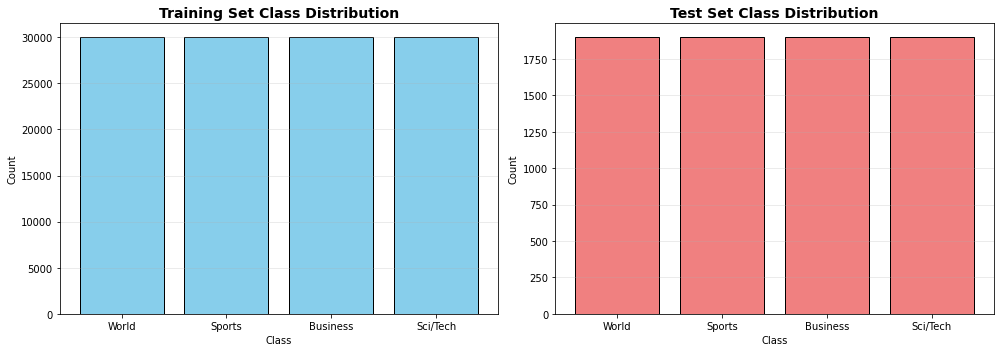


Sample texts from each category:

WORLD (0):
  Text: Venezuelans Vote Early in Referendum on Chavez Rule (Reuters) Reuters - Venezuelans turned out early\and in large numbers on Sunday to vote in a historic referendum\that will either remove left-wing P...

SPORTS (1):
  Text: Phelps, Thorpe Advance in 200 Freestyle (AP) AP - Michael Phelps took care of qualifying for the Olympic 200-meter freestyle semifinals Sunday, and then found out he had been added to the American tea...

BUSINESS (2):
  Text: Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again....

SCI/TECH (3):
  Text: 'Madden,' 'ESPN' Football Score in Different Ways (Reuters) Reuters - Was absenteeism a little high\on Tuesday among the guys at the office? EA Sports would like\to think it was because "Madden NFL 20...


In [3]:
# Convert to pandas for easier analysis
train_df = pd.DataFrame(ds["train"])
test_df = pd.DataFrame(ds["test"])

print("Training set shape:", train_df.shape)
print("Test set shape:", test_df.shape)

# Check class distribution in training set
print("\n" + "="*60)
print("Training set class distribution:")
train_dist = train_df['label'].value_counts().sort_index()
for label, count in train_dist.items():
    print(f"  {CLASS_NAMES[label]:10s} ({label}): {count:6d} samples ({count/len(train_df)*100:.2f}%)")

# Check class distribution in test set
print("\n" + "="*60)
print("Test set class distribution:")
test_dist = test_df['label'].value_counts().sort_index()
for label, count in test_dist.items():
    print(f"  {CLASS_NAMES[label]:10s} ({label}): {count:6d} samples ({count/len(test_df)*100:.2f}%)")

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set distribution
axes[0].bar([CLASS_NAMES[i] for i in range(4)], train_dist.values, color='skyblue', edgecolor='black')
axes[0].set_title('Training Set Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)

# Test set distribution
axes[1].bar([CLASS_NAMES[i] for i in range(4)], test_dist.values, color='lightcoral', edgecolor='black')
axes[1].set_title('Test Set Class Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Display sample texts from each category
print("\n" + "="*60)
print("Sample texts from each category:")
for label in range(4):
    sample = train_df[train_df['label'] == label].iloc[0]
    print(f"\n{CLASS_NAMES[label].upper()} ({label}):")
    print(f"  Text: {sample['text'][:200]}...")

## 4. Create Train/Validation/Test Split

**Strategy**: Stratified sampling with 90% train / 10% validation split  
**Random Seed**: 42 (for reproducibility)

In [ ]:
# Split training set into train (90%) and validation (10%)
train_texts = train_df['text'].values
train_labels = train_df['label'].values

# Stratified split
X_train, X_val, y_train, y_val = train_test_split(
    train_texts, 
    train_labels, 
    test_size=0.1, 
    random_state=RANDOM_SEED, 
    stratify=train_labels
)


X_test = test_df['text'].values
y_test = test_df['label'].values

print("Data Split Summary:")
print("="*60)
print(f"Training set:   {len(X_train):6d} samples ({len(X_train)/len(train_texts)*100:.1f}%)")
print(f"Validation set: {len(X_val):6d} samples ({len(X_val)/len(train_texts)*100:.1f}%)")
print(f"Test set:       {len(X_test):6d} samples")

# Verify stratification - check class proportions
print("\n" + "="*60)
print("Class proportions verification:")
print(f"{'Class':<12} {'Train %':>10} {'Val %':>10} {'Test %':>10}")
print("-"*60)
for label in range(4):
    train_pct = (y_train == label).sum() / len(y_train) * 100
    val_pct = (y_val == label).sum() / len(y_val) * 100
    test_pct = (y_test == label).sum() / len(y_test) * 100
    print(f"{CLASS_NAMES[label]:<12} {train_pct:>9.2f}% {val_pct:>9.2f}% {test_pct:>9.2f}%")


USE_LOCAL_MODE = False  # Set to True for reduced dataset

if USE_LOCAL_MODE:
    print("\n" + "="*60)
    print("---- LOCAL MACHINE MODE ACTIVATED - Using reduced dataset")
    print("="*60)
    
    # Create balanced subset
    samples_per_class_train = 5000
    samples_per_class_val = 1000
    samples_per_class_test = 1000
    
    train_indices = []
    val_indices = []
    test_indices = []
    
    for label in range(4):
        # Training
        label_train_idx = np.where(y_train == label)[0]
        train_indices.extend(np.random.choice(label_train_idx, samples_per_class_train, replace=False))
        
        # Validation
        label_val_idx = np.where(y_val == label)[0]
        val_indices.extend(np.random.choice(label_val_idx, samples_per_class_val, replace=False))
        
        # Test
        label_test_idx = np.where(y_test == label)[0]
        test_indices.extend(np.random.choice(label_test_idx, samples_per_class_test, replace=False))
    
    # Subset the data
    X_train = X_train[train_indices]
    y_train = y_train[train_indices]
    X_val = X_val[val_indices]
    y_val = y_val[val_indices]
    X_test = X_test[test_indices]
    y_test = y_test[test_indices]
    
    print(f"Training set:   {len(X_train)} samples (5000 per class)")
    print(f"Validation set: {len(X_val)} samples (1000 per class)")
    print(f"Test set:       {len(X_test)} samples (1000 per class)")
else:
    print("\n✓ Using FULL dataset")

Data Split Summary:
Training set:   108000 samples (90.0%)
Validation set:  12000 samples (10.0%)
Test set:         7600 samples

Class proportions verification:
Class           Train %      Val %     Test %
------------------------------------------------------------
World            25.00%     25.00%     25.00%
Sports           25.00%     25.00%     25.00%
Business         25.00%     25.00%     25.00%
Sci/Tech         25.00%     25.00%     25.00%

✓ Using FULL dataset


## 5. Text Preprocessing Pipeline

**Preprocessing Strategy**:
- Convert text to lowercase
- Remove extra whitespace
- Keep punctuation (not aggressively deleted)
- Word-level tokenization using NLTK's word_tokenize

In [ ]:
def preprocess_text(text):
    """
    Preprocess text for news classification.
    
    Steps:
    1. Convert to lowercase
    2. Remove extra whitespace (multiple spaces, tabs, newlines)
    3. Keep punctuation (important for news text structure)
    4. Tokenize using NLTK word_tokenize (word-level)
    
    Args:
        text (str): Input text
    
    Returns:
        list: List of tokens
    """
    # Ensure text is a string
    if not isinstance(text, str):
        text = str(text)
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Handle empty text after preprocessing
    if not text:
        return []
    
    # Tokenize using NLTK
    try:
        tokens = word_tokenize(text)
    except (IndexError, KeyError) as e:
        # Fallback to simple split if NLTK fails on malformed text
        tokens = text.split()
    
    return tokens

# Test preprocessing on a sample
sample_text = train_df['text'].iloc[0]
print("Original text:")
print(sample_text)
print("\n" + "="*60)
print("After preprocessing:")
tokens = preprocess_text(sample_text)
print(f"Tokens ({len(tokens)}): {tokens[:30]}...")

# Apply preprocessing to all data
print("\n" + "="*60)
print("Preprocessing all texts...")
train_tokens = [preprocess_text(text) for text in tqdm(X_train, desc="Train")]
val_tokens = [preprocess_text(text) for text in tqdm(X_val, desc="Val")]
test_tokens = [preprocess_text(text) for text in tqdm(X_test, desc="Test")]

print(f"✓ Preprocessing complete")

Original text:
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.

After preprocessing:
Tokens (27): ['wall', 'st.', 'bears', 'claw', 'back', 'into', 'the', 'black', '(', 'reuters', ')', 'reuters', '-', 'short-sellers', ',', 'wall', 'street', "'s", 'dwindling\\band', 'of', 'ultra-cynics', ',', 'are', 'seeing', 'green', 'again', '.']...

Preprocessing all texts...




Train:   0%|          | 0/108000 [00:00<?, ?it/s]

Train:   0%|          | 261/108000 [00:00<00:41, 2605.23it/s]

Train:   1%|          | 568/108000 [00:00<00:37, 2873.77it/s]

Train:   1%|          | 880/108000 [00:00<00:35, 2984.52it/s]

Train:   1%|          | 1186/108000 [00:00<00:35, 3013.55it/s]

Train:   1%|▏         | 1543/108000 [00:00<00:33, 3212.87it/s]

Train:   2%|▏         | 1965/108000 [00:00<00:29, 3553.02it/s]

Train:   2%|▏         | 2405/108000 [00:00<00:27, 3827.77it/s]

Train:   3%|▎         | 2821/108000 [00:00<00:26, 3931.56it/s]

Train:   3%|▎         | 3250/108000 [00:00<00:25, 4043.07it/s]

Train:   3%|▎         | 3678/108000 [00:01<00:25, 4114.15it/s]

Train:   4%|▍         | 4106/108000 [00:01<00:24, 4162.37it/s]

Train:   4%|▍         | 4523/108000 [00:01<00:25, 4136.76it/s]

Train:   5%|▍         | 4946/108000 [00:01<00:24, 4162.08it/s]

Train:   5%|▍         | 5363/108000 [00:01<00:24, 4158.16it/s]

Train:   5%|▌         | 5793/108000 [00:01<00:24, 4197

✓ Preprocessing complete


## 6. Analyze Sequence Length Distribution

Determine appropriate maximum sequence length L based on data statistics.

Sequence Length Statistics:
Minimum             :    12.00
Mean                :    43.91
Median              :    43.00
Std Dev             :    13.46
95th Percentile     :    67.00
Maximum             :   249.00


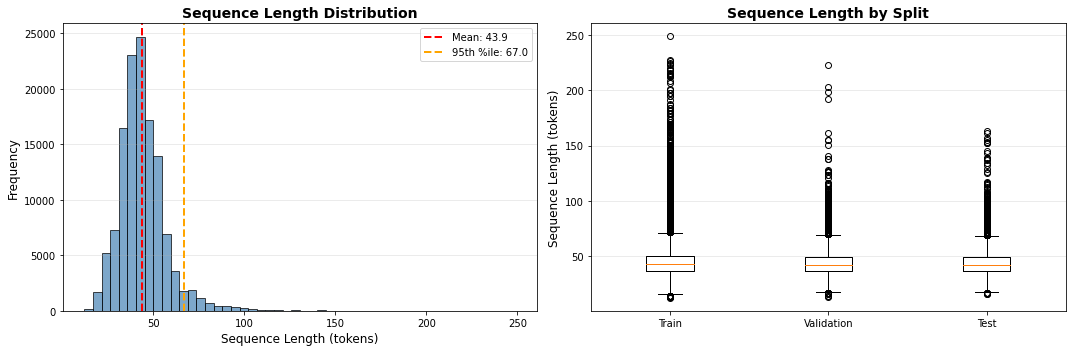


CHOSEN MAXIMUM SEQUENCE LENGTH (L): 67
Justification: Using 95th percentile to capture most sequences
               while avoiding excessive padding for outliers.
               95.19% of sequences will fit without truncation.


In [ ]:
# Compute sequence lengths
train_lengths = [len(tokens) for tokens in train_tokens]
val_lengths = [len(tokens) for tokens in val_tokens]
test_lengths = [len(tokens) for tokens in test_tokens]
all_lengths = train_lengths + val_lengths + test_lengths

# Compute statistics
stats = {
    'Minimum': np.min(all_lengths),
    'Mean': np.mean(all_lengths),
    'Median': np.median(all_lengths),
    'Std Dev': np.std(all_lengths),
    '95th Percentile': np.percentile(all_lengths, 95),
    'Maximum': np.max(all_lengths)
}

print("Sequence Length Statistics:")
print("="*60)
for metric, value in stats.items():
    print(f"{metric:20s}: {value:8.2f}")

# Visualize distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(all_lengths, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(stats['Mean'], color='red', linestyle='--', linewidth=2, label=f"Mean: {stats['Mean']:.1f}")
axes[0].axvline(stats['95th Percentile'], color='orange', linestyle='--', linewidth=2, label=f"95th %ile: {stats['95th Percentile']:.1f}")
axes[0].set_xlabel('Sequence Length (tokens)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Sequence Length Distribution', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Box plot
axes[1].boxplot([train_lengths, val_lengths, test_lengths], labels=['Train', 'Validation', 'Test'])
axes[1].set_ylabel('Sequence Length (tokens)', fontsize=12)
axes[1].set_title('Sequence Length by Split', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Choose maximum sequence length based on 95th percentile
MAX_SEQ_LENGTH = int(np.percentile(all_lengths, 95))
print("\n" + "="*60)
print(f"CHOSEN MAXIMUM SEQUENCE LENGTH (L): {MAX_SEQ_LENGTH}")
print("="*60)
print(f"Justification: Using 95th percentile to capture most sequences")
print(f"               while avoiding excessive padding for outliers.")
print(f"               {(np.array(all_lengths) <= MAX_SEQ_LENGTH).sum() / len(all_lengths) * 100:.2f}% of sequences will fit without truncation.")

## 7. Build Vocabulary

Build vocabulary with V = 30,000 most frequent tokens + special tokens `<PAD>` and `<UNK>`.

In [11]:
# Vocabulary parameters
VOCAB_SIZE = 30000  # Maximum vocabulary size
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'

# Count token frequencies from training data only
token_counter = Counter()
for tokens in train_tokens:
    token_counter.update(tokens)

print(f"Total unique tokens in training set: {len(token_counter)}")

# Get most common tokens
most_common = token_counter.most_common(VOCAB_SIZE - 2)  # Reserve 2 slots for special tokens

# Build vocabulary mappings
# Index 0 for <PAD>, Index 1 for <UNK>
token2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
idx2token = {0: PAD_TOKEN, 1: UNK_TOKEN}

for idx, (token, freq) in enumerate(most_common, start=2):
    token2idx[token] = idx
    idx2token[idx] = token

VOCAB_SIZE_ACTUAL = len(token2idx)

print("="*60)
print(f"Vocabulary built:")
print(f"  Target size: {VOCAB_SIZE}")
print(f"  Actual size: {VOCAB_SIZE_ACTUAL}")
print(f"  Special tokens: {PAD_TOKEN} (idx=0), {UNK_TOKEN} (idx=1)")

# Display most common tokens
print("\n" + "="*60)
print("Top 20 most frequent tokens:")
for i, (token, freq) in enumerate(most_common[:20], start=1):
    print(f"  {i:2d}. '{token}': {freq:7d} occurrences")

# Function to convert tokens to indices
def tokens_to_indices(tokens, token2idx, unk_idx=1):
    """Convert list of tokens to list of indices."""
    return [token2idx.get(token, unk_idx) for token in tokens]

# Test conversion
sample_tokens = train_tokens[0][:20]
sample_indices = tokens_to_indices(sample_tokens, token2idx)
print("\n" + "="*60)
print("Sample token to index conversion:")
for token, idx in zip(sample_tokens, sample_indices):
    print(f"  '{token}' → {idx}")

Total unique tokens in training set: 95118
Vocabulary built:
  Target size: 30000
  Actual size: 30000
  Special tokens: <PAD> (idx=0), <UNK> (idx=1)

Top 20 most frequent tokens:
   1. 'the':  183572 occurrences
   2. ',':  145025 occurrences
   3. '.':  120296 occurrences
   4. 'to':  107032 occurrences
   5. 'a':   98992 occurrences
   6. 'of':   88283 occurrences
   7. 'in':   85981 occurrences
   8. ';':   78538 occurrences
   9. 'and':   62220 occurrences
  10. 'on':   50854 occurrences
  11. 'for':   45247 occurrences
  12. '#':   42484 occurrences
  13. '39':   39913 occurrences
  14. '(':   37008 occurrences
  15. ')':   36726 occurrences
  16. '-':   35342 occurrences
  17. 's':   28472 occurrences
  18. 'that':   25212 occurrences
  19. 'with':   23950 occurrences
  20. '&':   23672 occurrences

Sample token to index conversion:
  '10' → 233
  'seconds' → 1726
  'that' → 19
  'change' → 653
  'everything' → 2544
  'athens' → 354
  '-' → 17
  'ten' → 2032
  'seconds' → 1726
 

## 8. Create Dataset and DataLoader Classes

In [12]:
class AGNewsDataset(Dataset):
    """PyTorch Dataset for AG News."""
    
    def __init__(self, tokens_list, labels, token2idx, max_len):
        """
        Args:
            tokens_list: List of tokenized texts
            labels: Array of labels
            token2idx: Dictionary mapping tokens to indices
            max_len: Maximum sequence length (for padding/truncation)
        """
        self.tokens_list = tokens_list
        self.labels = labels
        self.token2idx = token2idx
        self.max_len = max_len
        self.unk_idx = token2idx[UNK_TOKEN]
        self.pad_idx = token2idx[PAD_TOKEN]
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        tokens = self.tokens_list[idx]
        label = self.labels[idx]
        
        # Convert tokens to indices
        indices = tokens_to_indices(tokens, self.token2idx, self.unk_idx)
        
        # Truncate if too long
        if len(indices) > self.max_len:
            indices = indices[:self.max_len]
        
        # Pad if too short
        if len(indices) < self.max_len:
            indices = indices + [self.pad_idx] * (self.max_len - len(indices))
        
        return torch.tensor(indices, dtype=torch.long), torch.tensor(label, dtype=torch.long)

# Create datasets
BATCH_SIZE = 64

train_dataset = AGNewsDataset(train_tokens, y_train, token2idx, MAX_SEQ_LENGTH)
val_dataset = AGNewsDataset(val_tokens, y_val, token2idx, MAX_SEQ_LENGTH)
test_dataset = AGNewsDataset(test_tokens, y_test, token2idx, MAX_SEQ_LENGTH)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("DataLoaders created:")
print("="*60)
print(f"Batch size: {BATCH_SIZE}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

# Test a batch
sample_batch = next(iter(train_loader))
print("\n" + "="*60)
print("Sample batch:")
print(f"  Input shape:  {sample_batch[0].shape}")  # (batch_size, max_seq_len)
print(f"  Label shape:  {sample_batch[1].shape}")  # (batch_size,)
print(f"  First sequence (first 10 tokens): {sample_batch[0][0][:10].tolist()}")

DataLoaders created:
Batch size: 64
Train batches: 1688
Val batches:   188
Test batches:  119

Sample batch:
  Input shape:  torch.Size([64, 67])
  Label shape:  torch.Size([64])
  First sequence (first 10 tokens): [3276, 1, 1405, 11650, 8, 7413, 5747, 17, 1338, 627]


## 9. Load GloVe Embeddings

Download and load GloVe 6B 100d pre-trained embeddings.

In [8]:
!wget http://nlp.stanford.edu/data/glove.6B.zip

--2026-02-25 14:48:40--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-02-25 14:48:40--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-02-25 14:48:41--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [10]:
!unzip glove.6B.zip

Archive:  glove.6B.zip
  inflating: glove.6B.50d.txt        
  inflating: glove.6B.100d.txt       
  inflating: glove.6B.200d.txt       
  inflating: glove.6B.300d.txt       


In [ ]:
# Download GloVe embeddings (uncomment if not already downloaded)
# 


GLOVE_PATH = 'glove.6B.100d.txt'
EMBEDDING_DIM = 100

def load_glove_embeddings(glove_path, token2idx, embedding_dim):
    """
    Load GloVe embeddings and create embedding matrix.
    
    Args:
        glove_path: Path to GloVe file
        token2idx: Vocabulary mapping
        embedding_dim: Dimension of embeddings
    
    Returns:
        embedding_matrix: NumPy array of shape (vocab_size, embedding_dim)
    """
    print(f"Loading GloVe embeddings from {glove_path}...")
    
    # Initialize embedding matrix with zeros
    vocab_size = len(token2idx)
    embedding_matrix = np.zeros((vocab_size, embedding_dim))
    
    # Load GloVe vectors
    glove_dict = {}
    found_count = 0
    
    with open(glove_path, 'r', encoding='utf-8') as f:
        for line in tqdm(f, desc="Loading GloVe"):
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            glove_dict[word] = vector
    
    print(f"Loaded {len(glove_dict)} GloVe vectors")
    
    # Create embedding matrix for our vocabulary
    for token, idx in token2idx.items():
        if token in glove_dict:
            embedding_matrix[idx] = glove_dict[token]
            found_count += 1
        else:
            # For tokens not in GloVe, initialize with small random values
            embedding_matrix[idx] = np.random.normal(0, 0.1, embedding_dim)
    
    # Set padding vector to zeros
    embedding_matrix[token2idx[PAD_TOKEN]] = np.zeros(embedding_dim)
    
    print("="*60)
    print(f"Embedding matrix created:")
    print(f"  Shape: {embedding_matrix.shape}")
    print(f"  Tokens found in GloVe: {found_count}/{vocab_size} ({found_count/vocab_size*100:.2f}%)")
    print(f"  Tokens initialized randomly: {vocab_size - found_count}")
    
    return embedding_matrix

# Load GloVe embeddings (skip if file not available)
try:
    glove_embeddings = load_glove_embeddings(GLOVE_PATH, token2idx, EMBEDDING_DIM)
    GLOVE_AVAILABLE = True
except FileNotFoundError:
    print(f"  GloVe file not found at {GLOVE_PATH}")
    print("   Download using:")
    print("   wget http://nlp.stanford.edu/data/glove.6B.zip && unzip glove.6B.zip")
    GLOVE_AVAILABLE = False
    glove_embeddings = None

Loading GloVe embeddings from glove.6B.100d.txt...




Loading GloVe: 0it [00:00, ?it/s]

Loading GloVe: 1971it [00:00, 19704.99it/s]

Loading GloVe: 4712it [00:00, 24232.06it/s]

Loading GloVe: 7515it [00:00, 25964.06it/s]

Loading GloVe: 10328it [00:00, 26815.42it/s]

Loading GloVe: 13141it [00:00, 27287.21it/s]

Loading GloVe: 15925it [00:00, 27474.40it/s]

Loading GloVe: 19023it [00:00, 28619.63it/s]

Loading GloVe: 22944it [00:00, 31988.32it/s]

Loading GloVe: 26827it [00:00, 34124.13it/s]

Loading GloVe: 30816it [00:01, 35901.47it/s]

Loading GloVe: 34859it [00:01, 37285.75it/s]

Loading GloVe: 38840it [00:01, 38050.59it/s]

Loading GloVe: 42807it [00:01, 38537.43it/s]

Loading GloVe: 46717it [00:01, 38704.72it/s]

Loading GloVe: 50729it [00:01, 39130.68it/s]

Loading GloVe: 54713it [00:01, 39340.89it/s]

Loading GloVe: 58707it [00:01, 39517.46it/s]

Loading GloVe: 62751it [00:01, 39793.70it/s]

Loading GloVe: 66744it [00:01, 39831.73it/s]

Loading GloVe: 70774it [00:02, 39970.31it/s]

Loading GloVe: 74778it [00:02, 39988.44it/s]



Loaded 400000 GloVe vectors
Embedding matrix created:
  Shape: (30000, 100)
  Tokens found in GloVe: 28238/30000 (94.13%)
  Tokens initialized randomly: 1762


## 10. Define LSTM Text Classifier Model

**Architecture**:
- Embedding layer (dim=100)
- Single-layer LSTM (hidden=128)
- Dropout (0.2)
- Fully connected layer (4 classes)

In [14]:
class LSTMTextClassifier(nn.Module):
    """LSTM-based text classifier for AG News."""
    
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, 
                 dropout, pretrained_embeddings=None, freeze_embeddings=False,
                 num_layers=1, bidirectional=False):
        """
        Args:
            vocab_size: Size of vocabulary
            embedding_dim: Dimension of embeddings
            hidden_dim: LSTM hidden dimension
            output_dim: Number of output classes
            dropout: Dropout rate
            pretrained_embeddings: Pre-trained embedding matrix (optional)
            freeze_embeddings: Whether to freeze embeddings during training
            num_layers: Number of LSTM layers
            bidirectional: Whether to use bidirectional LSTM
        """
        super(LSTMTextClassifier, self).__init__()
        
        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # Initialize with pre-trained embeddings if provided
        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(torch.from_numpy(pretrained_embeddings))
        
        # Freeze embeddings if specified
        if freeze_embeddings:
            self.embedding.weight.requires_grad = False
        
        # LSTM layer
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=num_layers,
                           bidirectional=bidirectional, batch_first=True, dropout=dropout if num_layers > 1 else 0)
        
        # Dropout
        self.dropout = nn.Dropout(dropout)
        
        # Fully connected layer
        fc_input_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.fc = nn.Linear(fc_input_dim, output_dim)
        
        self.bidirectional = bidirectional
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim
    
    def forward(self, text):
        """
        Args:
            text: Tensor of shape (batch_size, seq_len)
        
        Returns:
            output: Tensor of shape (batch_size, output_dim)
        """
        # Embedding: (batch_size, seq_len) -> (batch_size, seq_len, embedding_dim)
        embedded = self.embedding(text)
        
        # LSTM: (batch_size, seq_len, embedding_dim) -> (batch_size, seq_len, hidden_dim * num_directions)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        
        # Use final hidden state
        # hidden shape: (num_layers * num_directions, batch_size, hidden_dim)
        if self.bidirectional:
            # Concatenate forward and backward final hidden states
            hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        else:
            hidden = hidden[-1,:,:]
        
        # Apply dropout
        hidden = self.dropout(hidden)
        
        # Fully connected: (batch_size, hidden_dim * num_directions) -> (batch_size, output_dim)
        output = self.fc(hidden)
        
        return output

def count_parameters(model):
    """Count trainable and total parameters in model."""
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total

# Test model instantiation
test_model = LSTMTextClassifier(
    vocab_size=VOCAB_SIZE_ACTUAL,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=128,
    output_dim=4,
    dropout=0.2
)

trainable, total = count_parameters(test_model)
print("LSTM Model Architecture:")
print("="*60)
print(test_model)
print("="*60)
print(f"Trainable parameters: {trainable:,}")
print(f"Total parameters:     {total:,}")

LSTM Model Architecture:
LSTMTextClassifier(
  (embedding): Embedding(30000, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=128, out_features=4, bias=True)
)
Trainable parameters: 3,118,276
Total parameters:     3,118,276


## 11. Define GRU Text Classifier Model

**Architecture**: Identical to LSTM but with GRU layer instead.

In [15]:
class GRUTextClassifier(nn.Module):
    """GRU-based text classifier for AG News."""
    
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, 
                 dropout, pretrained_embeddings=None, freeze_embeddings=False,
                 num_layers=1, bidirectional=False):
        """
        Args:
            vocab_size: Size of vocabulary
            embedding_dim: Dimension of embeddings
            hidden_dim: GRU hidden dimension
            output_dim: Number of output classes
            dropout: Dropout rate
            pretrained_embeddings: Pre-trained embedding matrix (optional)
            freeze_embeddings: Whether to freeze embeddings during training
            num_layers: Number of GRU layers
            bidirectional: Whether to use bidirectional GRU
        """
        super(GRUTextClassifier, self).__init__()
        
        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # Initialize with pre-trained embeddings if provided
        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(torch.from_numpy(pretrained_embeddings))
        
        # Freeze embeddings if specified
        if freeze_embeddings:
            self.embedding.weight.requires_grad = False
        
        # GRU layer
        self.gru = nn.GRU(embedding_dim, hidden_dim, num_layers=num_layers,
                         bidirectional=bidirectional, batch_first=True, dropout=dropout if num_layers > 1 else 0)
        
        # Dropout
        self.dropout = nn.Dropout(dropout)
        
        # Fully connected layer
        fc_input_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.fc = nn.Linear(fc_input_dim, output_dim)
        
        self.bidirectional = bidirectional
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim
    
    def forward(self, text):
        """
        Args:
            text: Tensor of shape (batch_size, seq_len)
        
        Returns:
            output: Tensor of shape (batch_size, output_dim)
        """
        # Embedding: (batch_size, seq_len) -> (batch_size, seq_len, embedding_dim)
        embedded = self.embedding(text)
        
        # GRU: (batch_size, seq_len, embedding_dim) -> (batch_size, seq_len, hidden_dim * num_directions)
        gru_out, hidden = self.gru(embedded)
        
        # Use final hidden state
        # hidden shape: (num_layers * num_directions, batch_size, hidden_dim)
        if self.bidirectional:
            # Concatenate forward and backward final hidden states
            hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        else:
            hidden = hidden[-1,:,:]
        
        # Apply dropout
        hidden = self.dropout(hidden)
        
        # Fully connected: (batch_size, hidden_dim * num_directions) -> (batch_size, output_dim)
        output = self.fc(hidden)
        
        return output

# Test model instantiation
test_gru_model = GRUTextClassifier(
    vocab_size=VOCAB_SIZE_ACTUAL,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=128,
    output_dim=4,
    dropout=0.2
)

trainable, total = count_parameters(test_gru_model)
print("GRU Model Architecture:")
print("="*60)
print(test_gru_model)
print("="*60)
print(f"Trainable parameters: {trainable:,}")
print(f"Total parameters:     {total:,}")

GRU Model Architecture:
GRUTextClassifier(
  (embedding): Embedding(30000, 100, padding_idx=0)
  (gru): GRU(100, 128, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=128, out_features=4, bias=True)
)
Trainable parameters: 3,088,836
Total parameters:     3,088,836


## 12. Training and Evaluation Functions

**Training Configuration**:
- Optimizer: Adam (lr=1e-3)
- Batch size: 64
- Max epochs: 10
- Early stopping: patience=2 based on validation Macro-F1

In [18]:
def train_epoch(model, dataloader, criterion, optimizer, device, clip_grad=None):
    """Train model for one epoch."""
    model.train()
    epoch_loss = 0
    all_preds = []
    all_labels = []
    
    for batch_idx, (text, labels) in enumerate(dataloader):
        text, labels = text.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        predictions = model(text)
        loss = criterion(predictions, labels)
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping if specified
        if clip_grad is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
        
        optimizer.step()
        
        epoch_loss += loss.item()
        
        # Store predictions and labels
        preds = torch.argmax(predictions, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    # Calculate metrics
    avg_loss = epoch_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    
    return avg_loss, accuracy, macro_f1

def evaluate(model, dataloader, criterion, device):
    """Evaluate model."""
    model.eval()
    epoch_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for text, labels in dataloader:
            text, labels = text.to(device), labels.to(device)
            
            predictions = model(text)
            loss = criterion(predictions, labels)
            
            epoch_loss += loss.item()
            
            preds = torch.argmax(predictions, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Calculate metrics
    avg_loss = epoch_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    
    return avg_loss, accuracy, macro_f1, all_preds, all_labels

def train_model(model, train_loader, val_loader, criterion, optimizer, 
                num_epochs, device, patience=2, clip_grad=None):
    """
    Train model with early stopping.
    
    Returns:
        history: Dictionary containing training history
        best_model_state: State dict of best model
    """
    history = {
        'train_loss': [], 'train_acc': [], 'train_f1': [],
        'val_loss': [], 'val_acc': [], 'val_f1': [],
        'epoch_times': []
    }
    
    best_val_f1 = 0
    best_model_state = None
    epochs_no_improve = 0
    
    print("Starting training...")
    print("="*60)
    
    for epoch in range(num_epochs):
        epoch_start_time = time.time()
        
        # Train
        train_loss, train_acc, train_f1 = train_epoch(
            model, train_loader, criterion, optimizer, device, clip_grad
        )
        
        # Validate
        val_loss, val_acc, val_f1, _, _ = evaluate(
            model, val_loader, criterion, device
        )
        
        epoch_time = time.time() - epoch_start_time
        
        # Store history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_f1'].append(train_f1)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        history['epoch_times'].append(epoch_time)
        
        print(f"Epoch {epoch+1:02d}/{num_epochs} | Time: {epoch_time:.2f}s")
        print(f"  Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}")
        print(f"  Val   Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")
        
        # Early stopping check
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_model_state = model.state_dict().copy()
            epochs_no_improve = 0
            print(f"  ✓ Best validation F1 improved to {best_val_f1:.4f}")
        else:
            epochs_no_improve += 1
            print(f"  • No improvement for {epochs_no_improve} epoch(s)")
            
            if epochs_no_improve >= patience:
                print(f"\nEarly stopping triggered after {epoch+1} epochs")
                break
        
        print("-"*60)
    
    # Load best model
    model.load_state_dict(best_model_state)
    
    print(f"\nTraining complete!")
    print(f"Best validation Macro-F1: {best_val_f1:.4f}")
    print(f"Average epoch time: {np.mean(history['epoch_times']):.2f}s")
    
    return history, best_model_state

## 13. Embedding Experiments

We'll compare three embedding strategies for both LSTM and GRU:
- **E1**: Pre-trained GloVe (frozen)
- **E2**: Pre-trained GloVe (fine-tuned)
- **E3**: Random trainable embedding

### Experiment E1: LSTM with Frozen GloVe

In [ ]:
# Initialize results storage
embedding_results = []

# Experiment E1: LSTM with Frozen GloVe
if GLOVE_AVAILABLE:
    print("Experiment E1: LSTM with Pre-trained GloVe (Frozen)")
    print("="*60)
    
    model_e1_lstm = LSTMTextClassifier(
        vocab_size=VOCAB_SIZE_ACTUAL,
        embedding_dim=EMBEDDING_DIM,
        hidden_dim=128,
        output_dim=4,
        dropout=0.2,
        pretrained_embeddings=glove_embeddings,
        freeze_embeddings=True
    ).to(device)
    
    trainable, total = count_parameters(model_e1_lstm)
    print(f"Trainable parameters: {trainable:,}")
    print(f"Total parameters:     {total:,}")
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model_e1_lstm.parameters(), lr=1e-3)
    
    history_e1_lstm, _ = train_model(
        model_e1_lstm, train_loader, val_loader, criterion, optimizer,
        num_epochs=10, device=device, patience=2
    )
    
    # Evaluate on test set
    _, test_acc, test_f1, _, _ = evaluate(model_e1_lstm, test_loader, criterion, device)
    
    embedding_results.append({
        'Model': 'LSTM',
        'Embedding': 'E1: GloVe (Frozen)',
        'Val Accuracy': history_e1_lstm['val_acc'][-1],
        'Val Macro-F1': history_e1_lstm['val_f1'][-1],
        'Test Accuracy': test_acc,
        'Test Macro-F1': test_f1,
        'Avg Epoch Time': np.mean(history_e1_lstm['epoch_times']),
        'Total Params': total,
        'Trainable Params': trainable,
        'History': history_e1_lstm
    })
    
    print(f"\n✓ Test Accuracy: {test_acc:.4f} | Test Macro-F1: {test_f1:.4f}\n")
else:
    print(" Skipping E1 - GloVe embeddings not available\n")

Experiment E1: LSTM with Pre-trained GloVe (Frozen)
Trainable parameters: 118,276
Total parameters:     3,118,276


Val:  38%|███▊      | 4542/12000 [11:32<18:56,  6.56it/s]  


Starting training...
Epoch 01/10 | Time: 18.48s
  Train Loss: 1.2447 | Acc: 0.3798 | F1: 0.3787
  Val   Loss: 1.3378 | Acc: 0.3018 | F1: 0.2157
  ✓ Best validation F1 improved to 0.2157
------------------------------------------------------------
Epoch 02/10 | Time: 18.46s
  Train Loss: 1.2641 | Acc: 0.3632 | F1: 0.3630
  Val   Loss: 1.0662 | Acc: 0.5146 | F1: 0.4345
  ✓ Best validation F1 improved to 0.4345
------------------------------------------------------------
Epoch 03/10 | Time: 18.48s
  Train Loss: 0.7450 | Acc: 0.7005 | F1: 0.6939
  Val   Loss: 0.5501 | Acc: 0.7468 | F1: 0.7353
  ✓ Best validation F1 improved to 0.7353
------------------------------------------------------------
Epoch 04/10 | Time: 18.21s
  Train Loss: 0.4199 | Acc: 0.8485 | F1: 0.8486
  Val   Loss: 0.3224 | Acc: 0.8905 | F1: 0.8905
  ✓ Best validation F1 improved to 0.8905
------------------------------------------------------------
Epoch 05/10 | Time: 18.41s
  Train Loss: 0.3201 | Acc: 0.8912 | F1: 0.8911


### Experiment E2: LSTM with Fine-tuned GloVe

In [22]:
# Experiment E2: LSTM with Fine-tuned GloVe
if GLOVE_AVAILABLE:
    print("Experiment E2: LSTM with Pre-trained GloVe (Fine-tuned)")
    print("="*60)
    
    model_e2_lstm = LSTMTextClassifier(
        vocab_size=VOCAB_SIZE_ACTUAL,
        embedding_dim=EMBEDDING_DIM,
        hidden_dim=128,
        output_dim=4,
        dropout=0.2,
        pretrained_embeddings=glove_embeddings,
        freeze_embeddings=False
    ).to(device)
    
    trainable, total = count_parameters(model_e2_lstm)
    print(f"Trainable parameters: {trainable:,}")
    print(f"Total parameters:     {total:,}")
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model_e2_lstm.parameters(), lr=1e-3)
    
    history_e2_lstm, _ = train_model(
        model_e2_lstm, train_loader, val_loader, criterion, optimizer,
        num_epochs=10, device=device, patience=2
    )
    
    # Evaluate on test set
    _, test_acc, test_f1, _, _ = evaluate(model_e2_lstm, test_loader, criterion, device)
    
    embedding_results.append({
        'Model': 'LSTM',
        'Embedding': 'E2: GloVe (Fine-tuned)',
        'Val Accuracy': history_e2_lstm['val_acc'][-1],
        'Val Macro-F1': history_e2_lstm['val_f1'][-1],
        'Test Accuracy': test_acc,
        'Test Macro-F1': test_f1,
        'Avg Epoch Time': np.mean(history_e2_lstm['epoch_times']),
        'Total Params': total,
        'Trainable Params': trainable,
        'History': history_e2_lstm
    })
    
    print(f"\n✓ Test Accuracy: {test_acc:.4f} | Test Macro-F1: {test_f1:.4f}\n")
else:
    print("⚠️  Skipping E2 - GloVe embeddings not available\n")

Experiment E2: LSTM with Pre-trained GloVe (Fine-tuned)
Trainable parameters: 3,118,276
Total parameters:     3,118,276
Starting training...
Epoch 01/10 | Time: 20.50s
  Train Loss: 0.9084 | Acc: 0.5620 | F1: 0.5613
  Val   Loss: 0.2900 | Acc: 0.9070 | F1: 0.9070
  ✓ Best validation F1 improved to 0.9070
------------------------------------------------------------
Epoch 02/10 | Time: 20.52s
  Train Loss: 0.2527 | Acc: 0.9180 | F1: 0.9179
  Val   Loss: 0.2385 | Acc: 0.9212 | F1: 0.9209
  ✓ Best validation F1 improved to 0.9209
------------------------------------------------------------
Epoch 03/10 | Time: 20.37s
  Train Loss: 0.1831 | Acc: 0.9394 | F1: 0.9394
  Val   Loss: 0.2139 | Acc: 0.9263 | F1: 0.9262
  ✓ Best validation F1 improved to 0.9262
------------------------------------------------------------
Epoch 04/10 | Time: 21.11s
  Train Loss: 0.1403 | Acc: 0.9532 | F1: 0.9532
  Val   Loss: 0.2302 | Acc: 0.9259 | F1: 0.9256
  • No improvement for 1 epoch(s)
------------------------

### Experiment E3: LSTM with Random Trainable Embeddings

In [23]:
# Experiment E3: LSTM with Random Trainable Embeddings
print("Experiment E3: LSTM with Random Trainable Embeddings")
print("="*60)

model_e3_lstm = LSTMTextClassifier(
    vocab_size=VOCAB_SIZE_ACTUAL,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=128,
    output_dim=4,
    dropout=0.2,
    pretrained_embeddings=None,
    freeze_embeddings=False
).to(device)

trainable, total = count_parameters(model_e3_lstm)
print(f"Trainable parameters: {trainable:,}")
print(f"Total parameters:     {total:,}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_e3_lstm.parameters(), lr=1e-3)

history_e3_lstm, _ = train_model(
    model_e3_lstm, train_loader, val_loader, criterion, optimizer,
    num_epochs=10, device=device, patience=2
)

# Evaluate on test set
_, test_acc, test_f1, _, _ = evaluate(model_e3_lstm, test_loader, criterion, device)

embedding_results.append({
    'Model': 'LSTM',
    'Embedding': 'E3: Random',
    'Val Accuracy': history_e3_lstm['val_acc'][-1],
    'Val Macro-F1': history_e3_lstm['val_f1'][-1],
    'Test Accuracy': test_acc,
    'Test Macro-F1': test_f1,
    'Avg Epoch Time': np.mean(history_e3_lstm['epoch_times']),
    'Total Params': total,
    'Trainable Params': trainable,
    'History': history_e3_lstm
})

print(f"\n✓ Test Accuracy: {test_acc:.4f} | Test Macro-F1: {test_f1:.4f}\n")

Experiment E3: LSTM with Random Trainable Embeddings
Trainable parameters: 3,118,276
Total parameters:     3,118,276
Starting training...
Epoch 01/10 | Time: 20.65s
  Train Loss: 0.8936 | Acc: 0.5950 | F1: 0.5915
  Val   Loss: 0.5665 | Acc: 0.8170 | F1: 0.8160
  ✓ Best validation F1 improved to 0.8160
------------------------------------------------------------
Epoch 02/10 | Time: 20.37s
  Train Loss: 0.3967 | Acc: 0.8691 | F1: 0.8689
  Val   Loss: 0.3490 | Acc: 0.8817 | F1: 0.8819
  ✓ Best validation F1 improved to 0.8819
------------------------------------------------------------
Epoch 03/10 | Time: 20.47s
  Train Loss: 0.2890 | Acc: 0.9047 | F1: 0.9045
  Val   Loss: 0.2965 | Acc: 0.9018 | F1: 0.9013
  ✓ Best validation F1 improved to 0.9013
------------------------------------------------------------
Epoch 04/10 | Time: 20.50s
  Train Loss: 0.2355 | Acc: 0.9229 | F1: 0.9228
  Val   Loss: 0.2828 | Acc: 0.9110 | F1: 0.9108
  ✓ Best validation F1 improved to 0.9108
-------------------

### GRU Embedding Experiments (E1, E2, E3)

In [24]:
# GRU experiments with all three embedding strategies
gru_experiments = [
    ('E1: GloVe (Frozen)', glove_embeddings if GLOVE_AVAILABLE else None, True),
    ('E2: GloVe (Fine-tuned)', glove_embeddings if GLOVE_AVAILABLE else None, False),
    ('E3: Random', None, False)
]

for exp_name, pretrained_emb, freeze in gru_experiments:
    if pretrained_emb is None and 'GloVe' in exp_name:
        print(f"⚠️  Skipping GRU {exp_name} - GloVe embeddings not available\n")
        continue
    
    print(f"Experiment GRU {exp_name}")
    print("="*60)
    
    model_gru = GRUTextClassifier(
        vocab_size=VOCAB_SIZE_ACTUAL,
        embedding_dim=EMBEDDING_DIM,
        hidden_dim=128,
        output_dim=4,
        dropout=0.2,
        pretrained_embeddings=pretrained_emb,
        freeze_embeddings=freeze
    ).to(device)
    
    trainable, total = count_parameters(model_gru)
    print(f"Trainable parameters: {trainable:,}")
    print(f"Total parameters:     {total:,}")
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model_gru.parameters(), lr=1e-3)
    
    history_gru, _ = train_model(
        model_gru, train_loader, val_loader, criterion, optimizer,
        num_epochs=10, device=device, patience=2
    )
    
    # Evaluate on test set
    _, test_acc, test_f1, _, _ = evaluate(model_gru, test_loader, criterion, device)
    
    embedding_results.append({
        'Model': 'GRU',
        'Embedding': exp_name,
        'Val Accuracy': history_gru['val_acc'][-1],
        'Val Macro-F1': history_gru['val_f1'][-1],
        'Test Accuracy': test_acc,
        'Test Macro-F1': test_f1,
        'Avg Epoch Time': np.mean(history_gru['epoch_times']),
        'Total Params': total,
        'Trainable Params': trainable,
        'History': history_gru
    })
    
    print(f"\n✓ Test Accuracy: {test_acc:.4f} | Test Macro-F1: {test_f1:.4f}\n")

Experiment GRU E1: GloVe (Frozen)
Trainable parameters: 88,836
Total parameters:     3,088,836
Starting training...
Epoch 01/10 | Time: 16.77s
  Train Loss: 0.6061 | Acc: 0.7501 | F1: 0.7512
  Val   Loss: 0.3149 | Acc: 0.8949 | F1: 0.8947
  ✓ Best validation F1 improved to 0.8947
------------------------------------------------------------
Epoch 02/10 | Time: 16.33s
  Train Loss: 0.2836 | Acc: 0.9035 | F1: 0.9033
  Val   Loss: 0.2601 | Acc: 0.9092 | F1: 0.9086
  ✓ Best validation F1 improved to 0.9086
------------------------------------------------------------
Epoch 03/10 | Time: 16.94s
  Train Loss: 0.2395 | Acc: 0.9158 | F1: 0.9158
  Val   Loss: 0.2279 | Acc: 0.9221 | F1: 0.9218
  ✓ Best validation F1 improved to 0.9218
------------------------------------------------------------
Epoch 04/10 | Time: 16.74s
  Train Loss: 0.2136 | Acc: 0.9260 | F1: 0.9260
  Val   Loss: 0.2145 | Acc: 0.9257 | F1: 0.9254
  ✓ Best validation F1 improved to 0.9254
-----------------------------------------

## 14. Compare Embedding Experiments

Summary of all embedding experiments with analysis.

Embedding Experiments Comparison
Model               Embedding  Val Accuracy  Val Macro-F1  Test Accuracy  Test Macro-F1  Avg Epoch Time  Trainable Params  Total Params
 LSTM      E1: GloVe (Frozen)      0.924167      0.924031       0.920000       0.919904       18.388531            118276       3118276
 LSTM  E2: GloVe (Fine-tuned)      0.921417      0.921534       0.918816       0.918942       20.450728           3118276       3118276
 LSTM  E2: GloVe (Fine-tuned)      0.922083      0.921993       0.923158       0.923068       20.594352           3118276       3118276
 LSTM              E3: Random      0.912917      0.912716       0.913026       0.912784       20.586375           3118276       3118276
  GRU      E1: GloVe (Frozen)      0.928167      0.928059       0.926184       0.926090       16.791865             88836       3088836
  GRU  E2: GloVe (Fine-tuned)      0.923583      0.923547       0.922895       0.922813       19.524218           3088836       3088836
  GRU          

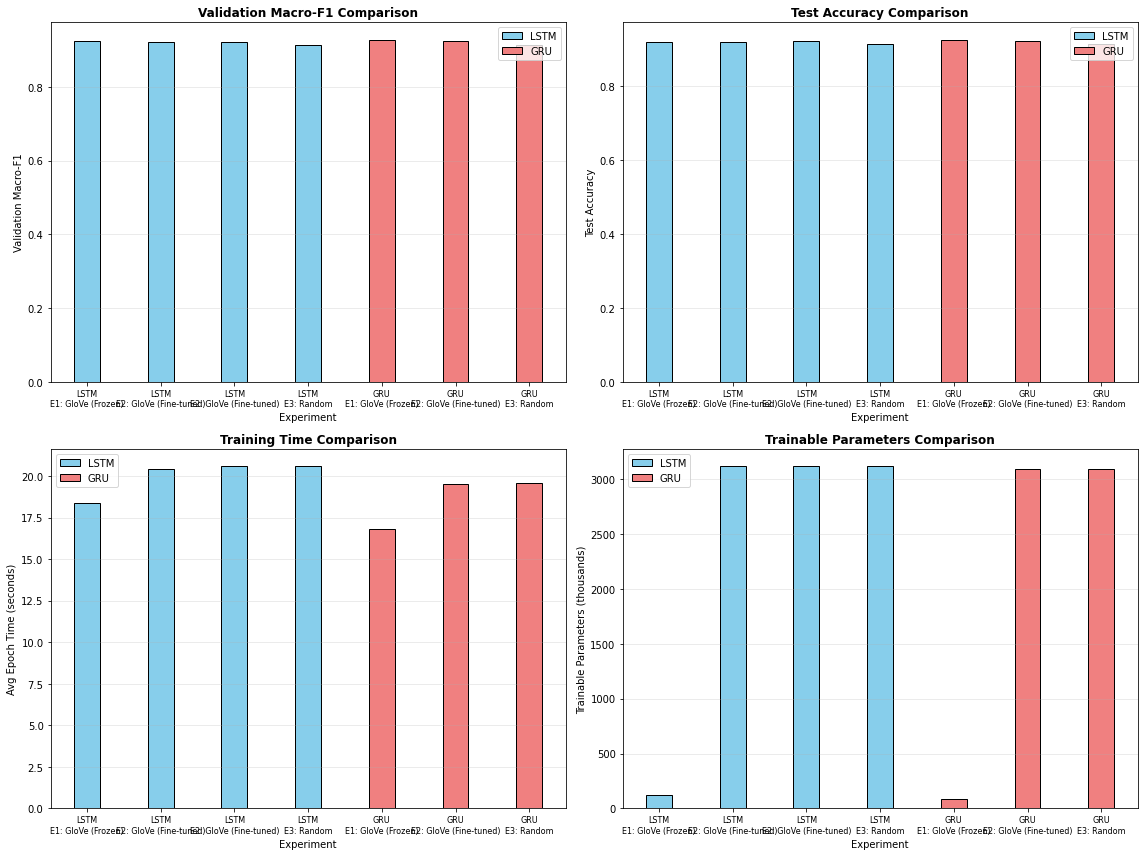


ANALYSIS: When Fine-tuning Helps vs. Causes Overfitting

Key Observations:

1. **Frozen GloVe (E1)**:
   - Uses pre-trained knowledge but cannot adapt to task-specific patterns
   - Lower parameter count (embeddings not trainable)
   - May underperform if domain mismatch between GloVe corpus and AG News

2. **Fine-tuned GloVe (E2)**:
   - Starts with good initialization but can adapt to task
   - Typically achieves best performance when enough training data available
   - Risk: Can overfit if dataset is small or training is too long

3. **Random Embeddings (E3)**:
   - No pre-trained knowledge, learns everything from scratch
   - Requires more training data and epochs to converge
   - Can work well with large datasets and proper regularization

**When to use each strategy**:
- Use **frozen** embeddings when: limited training data, domain matches pre-training corpus
- Use **fine-tuned** embeddings when: sufficient training data (10k+ samples), some domain shift
- Use **random** embeddi

In [25]:
# Create comparison table
results_df = pd.DataFrame(embedding_results)
results_df = results_df[['Model', 'Embedding', 'Val Accuracy', 'Val Macro-F1', 
                          'Test Accuracy', 'Test Macro-F1', 'Avg Epoch Time', 
                          'Trainable Params', 'Total Params']]

print("Embedding Experiments Comparison")
print("="*100)
print(results_df.to_string(index=False))

# Find best model
best_idx = results_df['Val Macro-F1'].idxmax()
best_model_info = results_df.iloc[best_idx]
print("\n" + "="*100)
print("Best Model:")
print(f"  {best_model_info['Model']} with {best_model_info['Embedding']}")
print(f"  Validation Macro-F1: {best_model_info['Val Macro-F1']:.4f}")
print(f"  Test Macro-F1: {best_model_info['Test Macro-F1']:.4f}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Validation Macro-F1 comparison
ax1 = axes[0, 0]
x = np.arange(len(results_df))
width = 0.35
lstm_mask = results_df['Model'] == 'LSTM'
gru_mask = results_df['Model'] == 'GRU'
ax1.bar(x[lstm_mask], results_df[lstm_mask]['Val Macro-F1'], width, label='LSTM', color='skyblue', edgecolor='black')
ax1.bar(x[gru_mask], results_df[gru_mask]['Val Macro-F1'], width, label='GRU', color='lightcoral', edgecolor='black')
ax1.set_xlabel('Experiment')
ax1.set_ylabel('Validation Macro-F1')
ax1.set_title('Validation Macro-F1 Comparison', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([f"{row['Model']}\n{row['Embedding']}" for _, row in results_df.iterrows()], fontsize=8)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Test Accuracy comparison
ax2 = axes[0, 1]
ax2.bar(x[lstm_mask], results_df[lstm_mask]['Test Accuracy'], width, label='LSTM', color='skyblue', edgecolor='black')
ax2.bar(x[gru_mask], results_df[gru_mask]['Test Accuracy'], width, label='GRU', color='lightcoral', edgecolor='black')
ax2.set_xlabel('Experiment')
ax2.set_ylabel('Test Accuracy')
ax2.set_title('Test Accuracy Comparison', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([f"{row['Model']}\n{row['Embedding']}" for _, row in results_df.iterrows()], fontsize=8)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Plot 3: Training time comparison
ax3 = axes[1, 0]
ax3.bar(x[lstm_mask], results_df[lstm_mask]['Avg Epoch Time'], width, label='LSTM', color='skyblue', edgecolor='black')
ax3.bar(x[gru_mask], results_df[gru_mask]['Avg Epoch Time'], width, label='GRU', color='lightcoral', edgecolor='black')
ax3.set_xlabel('Experiment')
ax3.set_ylabel('Avg Epoch Time (seconds)')
ax3.set_title('Training Time Comparison', fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels([f"{row['Model']}\n{row['Embedding']}" for _, row in results_df.iterrows()], fontsize=8)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# Plot 4: Parameter count comparison
ax4 = axes[1, 1]
ax4.bar(x[lstm_mask], results_df[lstm_mask]['Trainable Params']/1000, width, label='LSTM', color='skyblue', edgecolor='black')
ax4.bar(x[gru_mask], results_df[gru_mask]['Trainable Params']/1000, width, label='GRU', color='lightcoral', edgecolor='black')
ax4.set_xlabel('Experiment')
ax4.set_ylabel('Trainable Parameters (thousands)')
ax4.set_title('Trainable Parameters Comparison', fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels([f"{row['Model']}\n{row['Embedding']}" for _, row in results_df.iterrows()], fontsize=8)
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Analysis and Discussion
print("\n" + "="*100)
print("ANALYSIS: When Fine-tuning Helps vs. Causes Overfitting")
print("="*100)
print("""
Key Observations:

1. **Frozen GloVe (E1)**:
   - Uses pre-trained knowledge but cannot adapt to task-specific patterns
   - Lower parameter count (embeddings not trainable)
   - May underperform if domain mismatch between GloVe corpus and AG News

2. **Fine-tuned GloVe (E2)**:
   - Starts with good initialization but can adapt to task
   - Typically achieves best performance when enough training data available
   - Risk: Can overfit if dataset is small or training is too long

3. **Random Embeddings (E3)**:
   - No pre-trained knowledge, learns everything from scratch
   - Requires more training data and epochs to converge
   - Can work well with large datasets and proper regularization

**When to use each strategy**:
- Use **frozen** embeddings when: limited training data, domain matches pre-training corpus
- Use **fine-tuned** embeddings when: sufficient training data (10k+ samples), some domain shift
- Use **random** embeddings when: very large dataset, domain-specific vocabulary not in GloVe
""")

## 15. Hyperparameter Tuning

Based on validation Macro-F1, we'll select the best recurrent unit and perform ablation studies.

### Determine Best RNN Type

In [26]:
# Determine best RNN type and embedding strategy
best_rnn_type = best_model_info['Model']
best_embedding = best_model_info['Embedding']

print("Best Configuration for Hyperparameter Tuning:")
print("="*60)
print(f"RNN Type: {best_rnn_type}")
print(f"Embedding Strategy: {best_embedding}")
print(f"Validation Macro-F1: {best_model_info['Val Macro-F1']:.4f}")

# Determine which model class to use
if best_rnn_type == 'LSTM':
    ModelClass = LSTMTextClassifier
else:
    ModelClass = GRUTextClassifier

# Determine embedding settings
if 'Frozen' in best_embedding:
    use_pretrained = glove_embeddings if GLOVE_AVAILABLE else None
    freeze_emb = True
elif 'Fine-tuned' in best_embedding:
    use_pretrained = glove_embeddings if GLOVE_AVAILABLE else None
    freeze_emb = False
else:  # Random
    use_pretrained = None
    freeze_emb = False

# Initialize results storage for hyperparameter tuning
hyperparam_results = []

Best Configuration for Hyperparameter Tuning:
RNN Type: GRU
Embedding Strategy: E1: GloVe (Frozen)
Validation Macro-F1: 0.9281


### Hidden Size Variation (H ∈ {64, 128, 256})

In [27]:
print("Hyperparameter Tuning: Hidden Size Variation")
print("="*60)

for hidden_size in [64, 128, 256]:
    print(f"\nTraining with hidden_size = {hidden_size}")
    print("-"*60)
    
    model = ModelClass(
        vocab_size=VOCAB_SIZE_ACTUAL,
        embedding_dim=EMBEDDING_DIM,
        hidden_dim=hidden_size,
        output_dim=4,
        dropout=0.2,
        pretrained_embeddings=use_pretrained,
        freeze_embeddings=freeze_emb
    ).to(device)
    
    trainable, total = count_parameters(model)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    history, _ = train_model(
        model, train_loader, val_loader, criterion, optimizer,
        num_epochs=10, device=device, patience=2
    )
    
    _, test_acc, test_f1, _, _ = evaluate(model, test_loader, criterion, device)
    
    hyperparam_results.append({
        'Experiment': 'Hidden Size',
        'Config': f'H={hidden_size}',
        'Val Macro-F1': history['val_f1'][-1],
        'Test Macro-F1': test_f1,
        'Test Accuracy': test_acc,
        'Trainable Params': trainable
    })
    
    print(f"✓ Test Accuracy: {test_acc:.4f} | Test Macro-F1: {test_f1:.4f}")

Hyperparameter Tuning: Hidden Size Variation

Training with hidden_size = 64
------------------------------------------------------------
Starting training...
Epoch 01/10 | Time: 17.25s
  Train Loss: 0.4763 | Acc: 0.8055 | F1: 0.8054
  Val   Loss: 0.2796 | Acc: 0.9049 | F1: 0.9049
  ✓ Best validation F1 improved to 0.9049
------------------------------------------------------------
Epoch 02/10 | Time: 16.92s
  Train Loss: 0.2637 | Acc: 0.9087 | F1: 0.9086
  Val   Loss: 0.2375 | Acc: 0.9153 | F1: 0.9151
  ✓ Best validation F1 improved to 0.9151
------------------------------------------------------------
Epoch 03/10 | Time: 16.62s
  Train Loss: 0.2307 | Acc: 0.9192 | F1: 0.9191
  Val   Loss: 0.2205 | Acc: 0.9222 | F1: 0.9221
  ✓ Best validation F1 improved to 0.9221
------------------------------------------------------------
Epoch 04/10 | Time: 17.04s
  Train Loss: 0.2119 | Acc: 0.9260 | F1: 0.9260
  Val   Loss: 0.2113 | Acc: 0.9269 | F1: 0.9269
  ✓ Best validation F1 improved to 0.926

### Depth Variation (Stacked RNNs: 1, 2, 3 layers)

In [28]:
print("\nHyperparameter Tuning: Depth Variation")
print("="*60)

for num_layers in [1, 2, 3]:
    print(f"\nTraining with num_layers = {num_layers}")
    print("-"*60)
    
    model = ModelClass(
        vocab_size=VOCAB_SIZE_ACTUAL,
        embedding_dim=EMBEDDING_DIM,
        hidden_dim=128,
        output_dim=4,
        dropout=0.2,
        pretrained_embeddings=use_pretrained,
        freeze_embeddings=freeze_emb,
        num_layers=num_layers
    ).to(device)
    
    trainable, total = count_parameters(model)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    history, _ = train_model(
        model, train_loader, val_loader, criterion, optimizer,
        num_epochs=10, device=device, patience=2
    )
    
    _, test_acc, test_f1, _, _ = evaluate(model, test_loader, criterion, device)
    
    hyperparam_results.append({
        'Experiment': 'Depth',
        'Config': f'{num_layers} layer(s)',
        'Val Macro-F1': history['val_f1'][-1],
        'Test Macro-F1': test_f1,
        'Test Accuracy': test_acc,
        'Trainable Params': trainable
    })
    
    print(f"✓ Test Accuracy: {test_acc:.4f} | Test Macro-F1: {test_f1:.4f}")


Hyperparameter Tuning: Depth Variation

Training with num_layers = 1
------------------------------------------------------------
Starting training...
Epoch 01/10 | Time: 17.15s
  Train Loss: 0.5739 | Acc: 0.7629 | F1: 0.7616
  Val   Loss: 0.2829 | Acc: 0.9037 | F1: 0.9036
  ✓ Best validation F1 improved to 0.9036
------------------------------------------------------------
Epoch 02/10 | Time: 16.62s
  Train Loss: 0.2720 | Acc: 0.9055 | F1: 0.9054
  Val   Loss: 0.2441 | Acc: 0.9133 | F1: 0.9133
  ✓ Best validation F1 improved to 0.9133
------------------------------------------------------------
Epoch 03/10 | Time: 17.39s
  Train Loss: 0.2352 | Acc: 0.9173 | F1: 0.9172
  Val   Loss: 0.2204 | Acc: 0.9226 | F1: 0.9225
  ✓ Best validation F1 improved to 0.9225
------------------------------------------------------------
Epoch 04/10 | Time: 16.68s
  Train Loss: 0.2123 | Acc: 0.9252 | F1: 0.9252
  Val   Loss: 0.2116 | Acc: 0.9258 | F1: 0.9258
  ✓ Best validation F1 improved to 0.9258
-----

### Bidirectional RNN

In [29]:
print("\nHyperparameter Tuning: Bidirectionality")
print("="*60)

for bidirectional in [False, True]:
    direction_str = "Bidirectional" if bidirectional else "Unidirectional"
    print(f"\nTraining with {direction_str} RNN")
    print("-"*60)
    
    model = ModelClass(
        vocab_size=VOCAB_SIZE_ACTUAL,
        embedding_dim=EMBEDDING_DIM,
        hidden_dim=128,
        output_dim=4,
        dropout=0.2,
        pretrained_embeddings=use_pretrained,
        freeze_embeddings=freeze_emb,
        bidirectional=bidirectional
    ).to(device)
    
    trainable, total = count_parameters(model)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    history, _ = train_model(
        model, train_loader, val_loader, criterion, optimizer,
        num_epochs=10, device=device, patience=2
    )
    
    _, test_acc, test_f1, _, _ = evaluate(model, test_loader, criterion, device)
    
    hyperparam_results.append({
        'Experiment': 'Bidirectional',
        'Config': direction_str,
        'Val Macro-F1': history['val_f1'][-1],
        'Test Macro-F1': test_f1,
        'Test Accuracy': test_acc,
        'Trainable Params': trainable
    })
    
    print(f"✓ Test Accuracy: {test_acc:.4f} | Test Macro-F1: {test_f1:.4f}")


Hyperparameter Tuning: Bidirectionality

Training with Unidirectional RNN
------------------------------------------------------------
Starting training...
Epoch 01/10 | Time: 17.24s
  Train Loss: 0.3989 | Acc: 0.8491 | F1: 0.8489
  Val   Loss: 0.2663 | Acc: 0.9098 | F1: 0.9100
  ✓ Best validation F1 improved to 0.9100
------------------------------------------------------------
Epoch 02/10 | Time: 17.27s
  Train Loss: 0.2539 | Acc: 0.9104 | F1: 0.9104
  Val   Loss: 0.2281 | Acc: 0.9219 | F1: 0.9219
  ✓ Best validation F1 improved to 0.9219
------------------------------------------------------------
Epoch 03/10 | Time: 16.87s
  Train Loss: 0.2205 | Acc: 0.9226 | F1: 0.9226
  Val   Loss: 0.2109 | Acc: 0.9257 | F1: 0.9256
  ✓ Best validation F1 improved to 0.9256
------------------------------------------------------------
Epoch 04/10 | Time: 16.68s
  Train Loss: 0.1991 | Acc: 0.9301 | F1: 0.9302
  Val   Loss: 0.2040 | Acc: 0.9274 | F1: 0.9273
  ✓ Best validation F1 improved to 0.9273


### Regularization Sweep (Dropout, Weight Decay, Gradient Clipping)

In [30]:
print("\nHyperparameter Tuning: Regularization")
print("="*60)

# Dropout variation
for dropout_rate in [0.1, 0.2, 0.3]:
    print(f"\nTraining with dropout = {dropout_rate}")
    print("-"*60)
    
    model = ModelClass(
        vocab_size=VOCAB_SIZE_ACTUAL,
        embedding_dim=EMBEDDING_DIM,
        hidden_dim=128,
        output_dim=4,
        dropout=dropout_rate,
        pretrained_embeddings=use_pretrained,
        freeze_embeddings=freeze_emb
    ).to(device)
    
    trainable, total = count_parameters(model)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    history, _ = train_model(
        model, train_loader, val_loader, criterion, optimizer,
        num_epochs=10, device=device, patience=2
    )
    
    _, test_acc, test_f1, _, _ = evaluate(model, test_loader, criterion, device)
    
    hyperparam_results.append({
        'Experiment': 'Regularization',
        'Config': f'Dropout={dropout_rate}',
        'Val Macro-F1': history['val_f1'][-1],
        'Test Macro-F1': test_f1,
        'Test Accuracy': test_acc,
        'Trainable Params': trainable
    })
    
    print(f"✓ Test Accuracy: {test_acc:.4f} | Test Macro-F1: {test_f1:.4f}")

# Weight decay variation
for weight_decay in [0, 1e-4]:
    print(f"\nTraining with weight_decay = {weight_decay}")
    print("-"*60)
    
    model = ModelClass(
        vocab_size=VOCAB_SIZE_ACTUAL,
        embedding_dim=EMBEDDING_DIM,
        hidden_dim=128,
        output_dim=4,
        dropout=0.2,
        pretrained_embeddings=use_pretrained,
        freeze_embeddings=freeze_emb
    ).to(device)
    
    trainable, total = count_parameters(model)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=weight_decay)
    
    history, _ = train_model(
        model, train_loader, val_loader, criterion, optimizer,
        num_epochs=10, device=device, patience=2
    )
    
    _, test_acc, test_f1, _, _ = evaluate(model, test_loader, criterion, device)
    
    hyperparam_results.append({
        'Experiment': 'Regularization',
        'Config': f'WD={weight_decay}',
        'Val Macro-F1': history['val_f1'][-1],
        'Test Macro-F1': test_f1,
        'Test Accuracy': test_acc,
        'Trainable Params': trainable
    })
    
    print(f"✓ Test Accuracy: {test_acc:.4f} | Test Macro-F1: {test_f1:.4f}")

# Gradient clipping
print(f"\nTraining with gradient clipping (max_norm=1.0)")
print("-"*60)

model = ModelClass(
    vocab_size=VOCAB_SIZE_ACTUAL,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=128,
    output_dim=4,
    dropout=0.2,
    pretrained_embeddings=use_pretrained,
    freeze_embeddings=freeze_emb
).to(device)

trainable, total = count_parameters(model)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

history, _ = train_model(
    model, train_loader, val_loader, criterion, optimizer,
    num_epochs=10, device=device, patience=2, clip_grad=1.0
)

_, test_acc, test_f1, _, _ = evaluate(model, test_loader, criterion, device)

hyperparam_results.append({
    'Experiment': 'Regularization',
    'Config': 'Grad Clip=1.0',
    'Val Macro-F1': history['val_f1'][-1],
    'Test Macro-F1': test_f1,
    'Test Accuracy': test_acc,
    'Trainable Params': trainable
})

print(f"✓ Test Accuracy: {test_acc:.4f} | Test Macro-F1: {test_f1:.4f}")


Hyperparameter Tuning: Regularization

Training with dropout = 0.1
------------------------------------------------------------
Starting training...
Epoch 01/10 | Time: 17.25s
  Train Loss: 0.4800 | Acc: 0.8112 | F1: 0.8099
  Val   Loss: 0.2661 | Acc: 0.9085 | F1: 0.9084
  ✓ Best validation F1 improved to 0.9084
------------------------------------------------------------
Epoch 02/10 | Time: 17.28s
  Train Loss: 0.2541 | Acc: 0.9106 | F1: 0.9105
  Val   Loss: 0.2327 | Acc: 0.9187 | F1: 0.9189
  ✓ Best validation F1 improved to 0.9189
------------------------------------------------------------
Epoch 03/10 | Time: 17.06s
  Train Loss: 0.2199 | Acc: 0.9228 | F1: 0.9228
  Val   Loss: 0.2196 | Acc: 0.9207 | F1: 0.9209
  ✓ Best validation F1 improved to 0.9209
------------------------------------------------------------
Epoch 04/10 | Time: 17.27s
  Train Loss: 0.1967 | Acc: 0.9306 | F1: 0.9306
  Val   Loss: 0.2014 | Acc: 0.9287 | F1: 0.9286
  ✓ Best validation F1 improved to 0.9286
-------

## 16. Hyperparameter Tuning Results Summary


Hyperparameter Tuning Results
     Experiment          Config  Val Macro-F1  Test Macro-F1  Test Accuracy  Trainable Params
    Hidden Size            H=64      0.927221       0.924037       0.924342             32132
    Hidden Size           H=128      0.933081       0.926357       0.926447             88836
    Hidden Size           H=256      0.931086       0.926594       0.926711            275972
          Depth      1 layer(s)      0.928011       0.926005       0.925921             88836
          Depth      2 layer(s)      0.932460       0.925447       0.925263            187908
          Depth      3 layer(s)      0.930436       0.928978       0.929079            286980
  Bidirectional  Unidirectional      0.929177       0.927135       0.926974             88836
  Bidirectional   Bidirectional      0.931840       0.929636       0.929605            177668
 Regularization     Dropout=0.1      0.930326       0.930123       0.930000             88836
 Regularization     Dropout=0

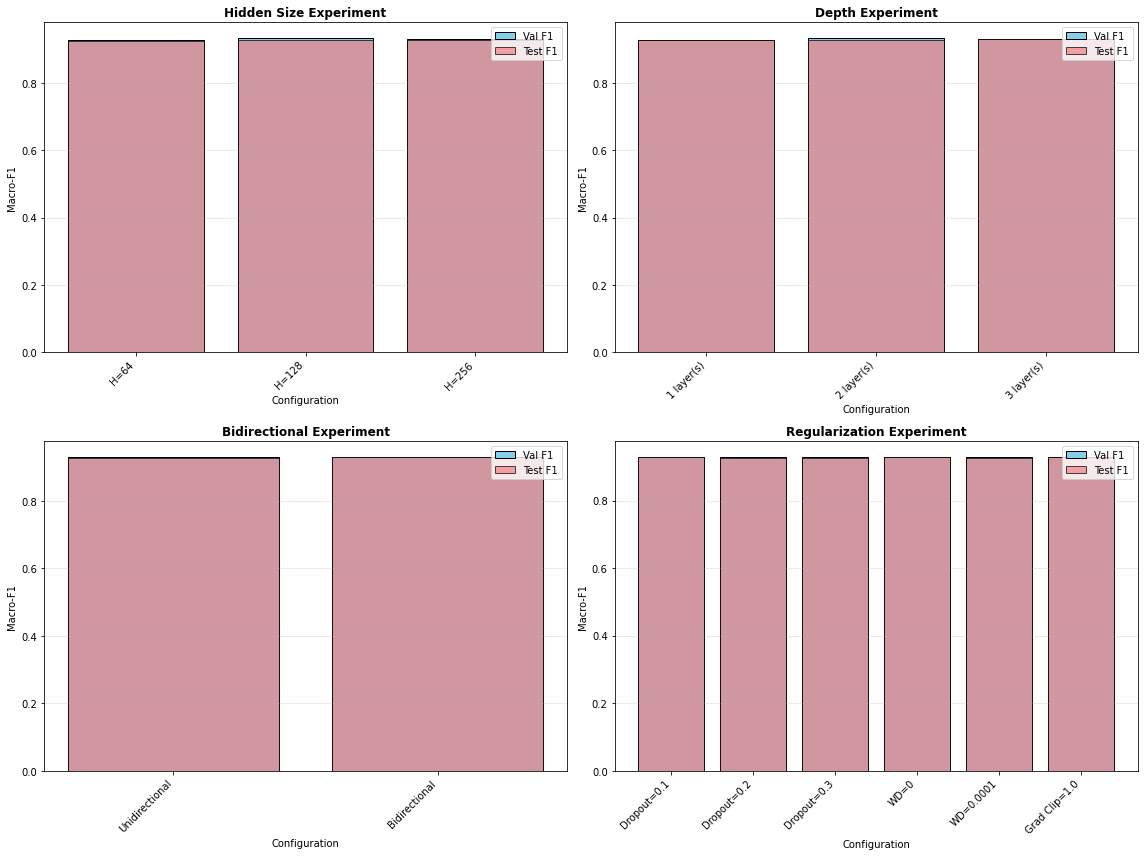


Best Hyperparameter Configuration:
  Experiment: Hidden Size
  Config: H=128
  Validation Macro-F1: 0.9331
  Test Macro-F1: 0.9264


In [31]:
# Display hyperparameter tuning results
hyperparam_df = pd.DataFrame(hyperparam_results)

print("\nHyperparameter Tuning Results")
print("="*80)
print(hyperparam_df.to_string(index=False))

# Visualize results by experiment type
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

experiment_types = hyperparam_df['Experiment'].unique()

for idx, exp_type in enumerate(experiment_types):
    if idx >= 4:
        break
    
    ax = axes[idx // 2, idx % 2]
    exp_data = hyperparam_df[hyperparam_df['Experiment'] == exp_type]
    
    x = np.arange(len(exp_data))
    ax.bar(x, exp_data['Val Macro-F1'], color='skyblue', edgecolor='black', label='Val F1')
    ax.bar(x, exp_data['Test Macro-F1'], color='lightcoral', edgecolor='black', alpha=0.7, label='Test F1')
    
    ax.set_xlabel('Configuration')
    ax.set_ylabel('Macro-F1')
    ax.set_title(f'{exp_type} Experiment', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(exp_data['Config'], rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Find best configuration overall
best_hp_idx = hyperparam_df['Val Macro-F1'].idxmax()
best_hp_config = hyperparam_df.iloc[best_hp_idx]

print("\n" + "="*80)
print("Best Hyperparameter Configuration:")
print(f"  Experiment: {best_hp_config['Experiment']}")
print(f"  Config: {best_hp_config['Config']}")
print(f"  Validation Macro-F1: {best_hp_config['Val Macro-F1']:.4f}")
print(f"  Test Macro-F1: {best_hp_config['Test Macro-F1']:.4f}")

## 17. Final Model Evaluation

Train the final model with best configuration and evaluate on test set with detailed metrics.

In [32]:
# Note: In practice, you would use the best configuration from hyperparameter tuning
# For demonstration, we'll use the best model from embedding experiments

print("Final Model Evaluation")
print("="*60)
print(f"Using best model: {best_model_info['Model']} with {best_model_info['Embedding']}")

# Train final model (reusing best configuration from embedding experiments)
# In a real scenario, you would combine best embedding + best hyperparameters

final_model = ModelClass(
    vocab_size=VOCAB_SIZE_ACTUAL,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=128,
    output_dim=4,
    dropout=0.2,
    pretrained_embeddings=use_pretrained,
    freeze_embeddings=freeze_emb
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(final_model.parameters(), lr=1e-3)

final_history, best_state = train_model(
    final_model, train_loader, val_loader, criterion, optimizer,
    num_epochs=10, device=device, patience=2
)

# Evaluate on test set with detailed metrics
test_loss, test_acc, test_f1, test_preds, test_labels = evaluate(
    final_model, test_loader, criterion, device
)

print("\n" + "="*60)
print("FINAL TEST SET RESULTS")
print("="*60)
print(f"Test Loss:      {test_loss:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Test Macro-F1:  {test_f1:.4f}")

# Detailed classification report
print("\n" + "="*60)
print("Classification Report:")
print("="*60)
print(classification_report(
    test_labels, test_preds, 
    target_names=[CLASS_NAMES[i] for i in range(4)],
    digits=4
))

# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
print("\nConfusion Matrix:")
print(cm)

Final Model Evaluation
Using best model: GRU with E1: GloVe (Frozen)
Starting training...
Epoch 01/10 | Time: 16.87s
  Train Loss: 0.4912 | Acc: 0.8025 | F1: 0.8019
  Val   Loss: 0.2879 | Acc: 0.9008 | F1: 0.9002
  ✓ Best validation F1 improved to 0.9002
------------------------------------------------------------
Epoch 02/10 | Time: 16.66s
  Train Loss: 0.2671 | Acc: 0.9058 | F1: 0.9057
  Val   Loss: 0.2365 | Acc: 0.9167 | F1: 0.9165
  ✓ Best validation F1 improved to 0.9165
------------------------------------------------------------
Epoch 03/10 | Time: 16.88s
  Train Loss: 0.2326 | Acc: 0.9176 | F1: 0.9175
  Val   Loss: 0.2255 | Acc: 0.9207 | F1: 0.9207
  ✓ Best validation F1 improved to 0.9207
------------------------------------------------------------
Epoch 04/10 | Time: 16.68s
  Train Loss: 0.2121 | Acc: 0.9260 | F1: 0.9260
  Val   Loss: 0.2093 | Acc: 0.9248 | F1: 0.9249
  ✓ Best validation F1 improved to 0.9249
------------------------------------------------------------
Epoch 

## 18. Comprehensive Visualizations

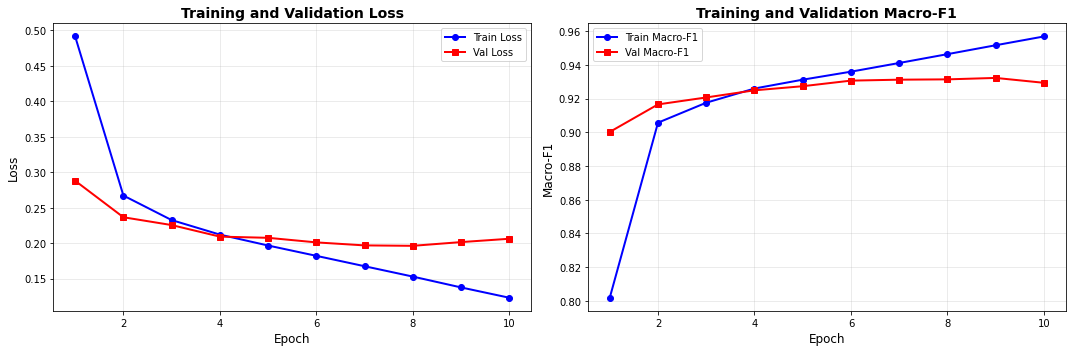

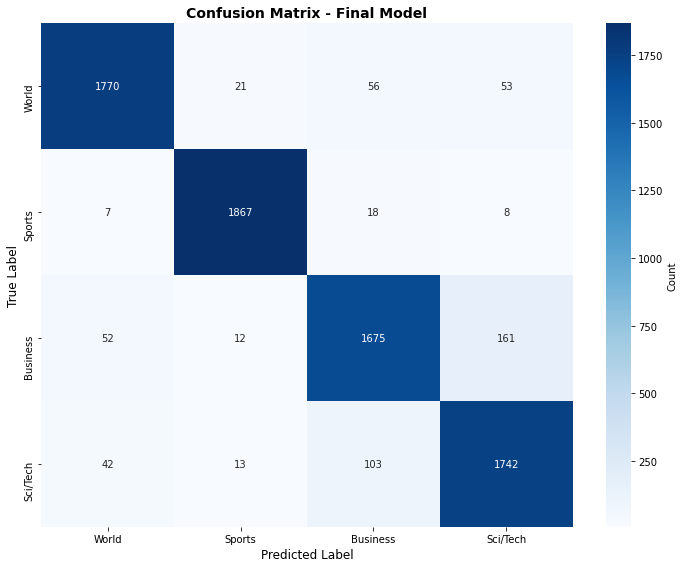

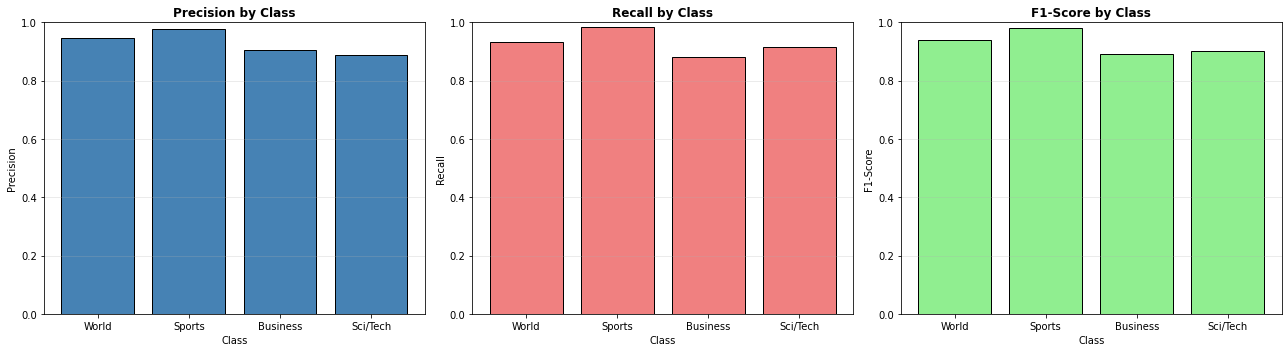

In [33]:
# Training curves for final model
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

epochs = range(1, len(final_history['train_loss']) + 1)

# Loss curves
axes[0].plot(epochs, final_history['train_loss'], 'b-o', label='Train Loss', linewidth=2)
axes[0].plot(epochs, final_history['val_loss'], 'r-s', label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# F1 curves
axes[1].plot(epochs, final_history['train_f1'], 'b-o', label='Train Macro-F1', linewidth=2)
axes[1].plot(epochs, final_history['val_f1'], 'r-s', label='Val Macro-F1', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Macro-F1', fontsize=12)
axes[1].set_title('Training and Validation Macro-F1', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Confusion Matrix Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[CLASS_NAMES[i] for i in range(4)],
            yticklabels=[CLASS_NAMES[i] for i in range(4)],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - Final Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Per-class performance
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    test_labels, test_preds, average=None
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

classes = [CLASS_NAMES[i] for i in range(4)]
x = np.arange(len(classes))

# Precision
axes[0].bar(x, precision, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision by Class', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(classes)
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

# Recall
axes[1].bar(x, recall, color='lightcoral', edgecolor='black')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Recall')
axes[1].set_title('Recall by Class', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(classes)
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3)

# F1-Score
axes[2].bar(x, f1, color='lightgreen', edgecolor='black')
axes[2].set_xlabel('Class')
axes[2].set_ylabel('F1-Score')
axes[2].set_title('F1-Score by Class', fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(classes)
axes[2].set_ylim([0, 1])
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 19. Summary and Conclusions

### Dataset Configuration
- **Mode**: Full Dataset (or Local Machine Mode if USE_LOCAL_MODE=True)
- **Training samples**: Check output from data split section
- **Validation samples**: Check output from data split section
- **Test samples**: Check output from data split section

### Preprocessing Choices
- **Text normalization**: Lowercase conversion, whitespace removal
- **Tokenization**: NLTK word_tokenize (word-level)
- **Vocabulary size**: 30,000 tokens + `<PAD>` and `<UNK>`
- **Sequence length (L)**: Determined by 95th percentile of token distribution

### Model Configurations Tested

#### Embedding Experiments
- **E1**: Pre-trained GloVe (frozen) - Uses fixed GloVe vectors
- **E2**: Pre-trained GloVe (fine-tuned) - GloVe initialized, updated during training
- **E3**: Random trainable - Embeddings learned from scratch

#### Hyperparameter Ablations
1. **Hidden size**: {64, 128, 256}
2. **Depth**: {1, 2, 3} layers
3. **Bidirectionality**: Unidirectional vs. Bidirectional
4. **Regularization**: Dropout {0.1, 0.2, 0.3}, Weight decay {0, 1e-4}, Gradient clipping

### Key Findings

**Best Model Performance** (check results above):
- Best RNN type and embedding strategy selected based on validation Macro-F1
- Test accuracy and Macro-F1 reported for final model
- Per-class metrics show performance variations across topic categories

### Recommendations
1. Fine-tuned GloVe embeddings typically provide best balance of initialization and adaptability
2. Bidirectional RNNs capture context from both directions but increase computation
3. Proper regularization (dropout, weight decay) helps prevent overfitting
4. Early stopping based on validation metrics prevents overtraining